In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")
import os , sys

# **Dataset link:-** 
***Dataset is very large , use this link***

**https://www.kaggle.com/datasets/himanshupoddar/zomato-bangalore-restaurants**

In [2]:
#Using utils Funtion to export data from mongodb , to use this make sure to create .env file with MONGO_DB_URL and Run data_dump.py file
file_path = os.path.join(os.getcwd() , "dataset/zomato.csv")
df = pd.read_csv(file_path)
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/new-friends-b...,"12/11, Opposite SBM Bank, 20th Main, 100 Feet ...",New Friends,Yes,No,3.8 /5,273,080 26784129\n080 26912010,BTM,Casual Dining,"Fritters, Lasagne, Biryani, Fish, Pasta, Draug...","North Indian, Continental, Chinese, Steak",900,"[('Rated 5.0', 'RATED\n Our team dinner was a...","['Friends Special Cocktail', 'Veg Hot Pot', 'C...",Dine-out,Koramangala 7th Block
1,https://www.zomato.com/bangalore/the-chennai-e...,"60/1, Double Road, Indiranagar, Bangalore",The Chennai Express,No,No,3.8/5,166,080 68888856,Indiranagar,Quick Bites,"Idli, Filter Coffee, Vada Curry, Podi Dosa, Sw...","South Indian, Chinese",200,"[('Rated 5.0', ""RATED\n Well , amidst the var...",[],Dine-out,Indiranagar
2,https://www.zomato.com/bangalore/the-blue-wago...,"615/1, Ground Floor, Janardhan Mansion, 10th C...",The Blue Wagon - Kitchen,Yes,No,4.6/5,228,+91 8105485007\r\n+91 8095904280,Jayanagar,Cafe,"Pizza, Nachos, Garlic Maggi, Burgers, Cheese M...","Cafe, Beverages",400,"[('Rated 5.0', ""RATED\n I've been binging on ...",[],Delivery,Basavanagudi
3,https://www.zomato.com/bangalore/monsoon-bella...,"The Bay, Campus 8A, RMZ Ecoworld, Bellandur, B...",Monsoon,No,No,2.8 /5,12,+91 9885576726,Bellandur,Food Court,NaN,Continental,"1,000","[('Rated 3.0', 'RATED\n This place serves som...",[],Buffet,Sarjapur Road
4,https://www.zomato.com/bangalore/ambur-biryani...,"74, veerabadrappa cross, R.s .palya, Kammanaha...",Ambur Biryani,No,No,NaN,0,+91 8660043859,Kammanahalli,Quick Bites,NaN,"Biryani, Kebab",250,[],[],Dine-out,Kalyan Nagar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,https://www.zomato.com/bangalore/biryani-darba...,"Velankini Road, Opposite HP Suryawave Building...",Biryani Darbar,Yes,No,NEW,0,080 49652545,Electronic City,Quick Bites,NaN,"Biryani, Andhra, Chinese, North Indian",550,"[('Rated 3.0', 'RATED\n the quantity which th...",[],Dine-out,Electronic City
39996,https://www.zomato.com/bangalore/cafe-medley-k...,"473, KHB Colony, 17th C Main, Koramangala 5th ...",Cafe Medley,Yes,No,4.2/5,1059,+91 8041160865\r\r\n+91 9845141475,Koramangala 5th Block,Cafe,"Coffee, Burgers, Pasta, Sandwiches, Mudcake, C...","Cafe, Continental, Burger",800,"[('Rated 1.0', 'RATED\n The place got me stom...","['Masala Omelette', 'The Big Breakfast', 'Gril...",Delivery,BTM
39997,https://www.zomato.com/bangalore/malabar-treat...,"6th Main Rd, M S R Nagar, Mathikere, Yeshwantp...",Malabar Treat,No,No,NaN,0,+91 7026060804,Yeshwantpur,Quick Bites,NaN,"North Indian, Arabian, South Indian, Chinese",500,[],[],Dine-out,New BEL Road
39998,https://www.zomato.com/bangalore/kaara-by-the-...,"119, Annaswamy Mudaliar Road, Opposite Ulsoor ...",KAARA BY THE LAKE,No,No,4.0/5,47,+91 8025565676,Ulsoor,Cafe,"Coffee, Pizza, Pasta, Key Lime Pie","Cafe, Italian, Coffee",750,"[('Rated 4.0', ""RATED\n One of my go-to resta...",[],Cafes,Frazer Town


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          40000 non-null  object
 1   address                      40000 non-null  object
 2   name                         40000 non-null  object
 3   online_order                 40000 non-null  object
 4   book_table                   40000 non-null  object
 5   rate                         33911 non-null  object
 6   votes                        40000 non-null  int64 
 7   phone                        39049 non-null  object
 8   location                     39982 non-null  object
 9   rest_type                    39825 non-null  object
 10  dish_liked                   18290 non-null  object
 11  cuisines                     39962 non-null  object
 12  approx_cost(for two people)  39719 non-null  object
 13  reviews_list                 40

In [4]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            6089
votes                              0
phone                            951
location                          18
rest_type                        175
dish_liked                     21710
cuisines                          38
approx_cost(for two people)      281
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

***By viewing this dish_liked  column has more than 20000 null values , which is more than half of total no. of entries inside dish_liked column .***

In [5]:
df.duplicated().sum()

0

# **Let Handle null values and clean dish_liked column**

In [6]:
df["dish_liked"]=df["dish_liked"].fillna(df["dish_liked"].mode()[0]) #replacing null with most occuring dish
df["dish_liked"]

0        Fritters, Lasagne, Biryani, Fish, Pasta, Draug...
1        Idli, Filter Coffee, Vada Curry, Podi Dosa, Sw...
2        Pizza, Nachos, Garlic Maggi, Burgers, Cheese M...
3                                                  Biryani
4                                                  Biryani
                               ...                        
39995                                              Biryani
39996    Coffee, Burgers, Pasta, Sandwiches, Mudcake, C...
39997                                              Biryani
39998                   Coffee, Pizza, Pasta, Key Lime Pie
39999                                              Biryani
Name: dish_liked, Length: 40000, dtype: object

In [7]:
df["menu_item"]

0        ['Friends Special Cocktail', 'Veg Hot Pot', 'C...
1                                                       []
2                                                       []
3                                                       []
4                                                       []
                               ...                        
39995                                                   []
39996    ['Masala Omelette', 'The Big Breakfast', 'Gril...
39997                                                   []
39998                                                   []
39999                                                   []
Name: menu_item, Length: 40000, dtype: object

# **Observe Junk name**

In [8]:
df[df["name"]=="Lifetree CafÃ\x83Â\x83Ã\x82Â\x83Ã\x83Â\x82Ã\x82Â\x83Ã\x83Â\x83Ã\x82Â\x82Ã\x83Â\x82Ã\x82Â©"] #Observe junk name inside name column 
df.iloc[20690 , 0] ="Lifetree Cafe"  #Changing junk name into a easy readable name
df.iloc[20690 , 0]

'Lifetree Cafe'

In [9]:
df.iloc[20690 , 0]

'Lifetree Cafe'

In [10]:
df["dish_liked"]=df["dish_liked"].str.strip()



In [11]:
df["dish_liked"]=df["dish_liked"].str.split(", ")


In [12]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/new-friends-b...,"12/11, Opposite SBM Bank, 20th Main, 100 Feet ...",New Friends,Yes,No,3.8 /5,273,080 26784129\n080 26912010,BTM,Casual Dining,"[Fritters, Lasagne, Biryani, Fish, Pasta, Drau...","North Indian, Continental, Chinese, Steak",900,"[('Rated 5.0', 'RATED\n Our team dinner was a...","['Friends Special Cocktail', 'Veg Hot Pot', 'C...",Dine-out,Koramangala 7th Block
1,https://www.zomato.com/bangalore/the-chennai-e...,"60/1, Double Road, Indiranagar, Bangalore",The Chennai Express,No,No,3.8/5,166,080 68888856,Indiranagar,Quick Bites,"[Idli, Filter Coffee, Vada Curry, Podi Dosa, S...","South Indian, Chinese",200,"[('Rated 5.0', ""RATED\n Well , amidst the var...",[],Dine-out,Indiranagar
2,https://www.zomato.com/bangalore/the-blue-wago...,"615/1, Ground Floor, Janardhan Mansion, 10th C...",The Blue Wagon - Kitchen,Yes,No,4.6/5,228,+91 8105485007\r\n+91 8095904280,Jayanagar,Cafe,"[Pizza, Nachos, Garlic Maggi, Burgers, Cheese ...","Cafe, Beverages",400,"[('Rated 5.0', ""RATED\n I've been binging on ...",[],Delivery,Basavanagudi
3,https://www.zomato.com/bangalore/monsoon-bella...,"The Bay, Campus 8A, RMZ Ecoworld, Bellandur, B...",Monsoon,No,No,2.8 /5,12,+91 9885576726,Bellandur,Food Court,[Biryani],Continental,"1,000","[('Rated 3.0', 'RATED\n This place serves som...",[],Buffet,Sarjapur Road
4,https://www.zomato.com/bangalore/ambur-biryani...,"74, veerabadrappa cross, R.s .palya, Kammanaha...",Ambur Biryani,No,No,NaN,0,+91 8660043859,Kammanahalli,Quick Bites,[Biryani],"Biryani, Kebab",250,[],[],Dine-out,Kalyan Nagar


In [13]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

# **lets drop unnecessary /irrelavents features from a dataframe**

In [14]:
features_to_drop=['url', 'address','phone' ,'listed_in(type)' ,'reviews_list' , "menu_item"]
df = df.drop(features_to_drop , axis=1 )
df.head(2)

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(city)
0,New Friends,Yes,No,3.8 /5,273,BTM,Casual Dining,"[Fritters, Lasagne, Biryani, Fish, Pasta, Drau...","North Indian, Continental, Chinese, Steak",900,Koramangala 7th Block
1,The Chennai Express,No,No,3.8/5,166,Indiranagar,Quick Bites,"[Idli, Filter Coffee, Vada Curry, Podi Dosa, S...","South Indian, Chinese",200,Indiranagar


**Lets handle and clean features with null values**

In [15]:
df.isnull().sum()

name                              0
online_order                      0
book_table                        0
rate                           6089
votes                             0
location                         18
rest_type                       175
dish_liked                        0
cuisines                         38
approx_cost(for two people)     281
listed_in(city)                   0
dtype: int64

`lets handle rate(rating features) which is our target column with median values.`

In [16]:
df["rate"].unique() 

array(['3.8 /5', '3.8/5', '4.6/5', '2.8 /5', nan, '4.0 /5', '3.6/5',
       '4.1 /5', '3.2 /5', 'NEW', '3.3 /5', '3.9/5', '4.4 /5', '3.4/5',
       '4.0/5', '3.7 /5', '2.9 /5', '3.1 /5', '3.4 /5', '2.8/5', '-',
       '3.9 /5', '4.4/5', '3.2/5', '3.3/5', '3.5/5', '3.6 /5', '3.7/5',
       '2.6/5', '4.2/5', '4.1/5', '2.7 /5', '4.2 /5', '3.0 /5', '4.3 /5',
       '3.5 /5', '4.3/5', '2.3 /5', '2.7/5', '4.9 /5', '3.0/5', '2.6 /5',
       '4.5 /5', '4.6 /5', '2.5 /5', '3.1/5', '2.4 /5', '4.5/5', '2.9/5',
       '4.7/5', '4.8/5', '4.7 /5', '2.5/5', '2.4/5', '2.0 /5', '4.8 /5',
       '2.3/5', '2.2/5', '4.9/5', '2.1 /5', '2.0/5', '1.8/5', '2.1/5',
       '2.2 /5', '1.8 /5'], dtype=object)

**Lets first remove garbage VALUES  from rate column such as "/5" , which is unnecessary and also REPLACE labels like nan and NEW with NAN VALUES**

In [17]:
df["rate"]=df['rate'].str.replace("/5" , "")
df["rate"]=df['rate'].str.replace("NEW" ,"NaN")
df["rate"]=df['rate'].str.replace("nan" ,"NaN")
df["rate"]=df['rate'].str.replace("-" ,"NaN")

df["rate"].unique()

array(['3.8 ', '3.8', '4.6', '2.8 ', nan, '4.0 ', '3.6', '4.1 ', '3.2 ',
       'NaN', '3.3 ', '3.9', '4.4 ', '3.4', '4.0', '3.7 ', '2.9 ', '3.1 ',
       '3.4 ', '2.8', '3.9 ', '4.4', '3.2', '3.3', '3.5', '3.6 ', '3.7',
       '2.6', '4.2', '4.1', '2.7 ', '4.2 ', '3.0 ', '4.3 ', '3.5 ', '4.3',
       '2.3 ', '2.7', '4.9 ', '3.0', '2.6 ', '4.5 ', '4.6 ', '2.5 ',
       '3.1', '2.4 ', '4.5', '2.9', '4.7', '4.8', '4.7 ', '2.5', '2.4',
       '2.0 ', '4.8 ', '2.3', '2.2', '4.9', '2.1 ', '2.0', '1.8', '2.1',
       '2.2 ', '1.8 '], dtype=object)

In [18]:
#Lets replace null values with average after converting rate column to float
df["rate"]=df["rate"].astype(float)
df["rate"]=df["rate"].fillna(df["rate"].median())
df["rate"].unique()

array([3.8, 4.6, 2.8, 3.7, 4. , 3.6, 4.1, 3.2, 3.3, 3.9, 4.4, 3.4, 2.9,
       3.1, 3.5, 2.6, 4.2, 2.7, 3. , 4.3, 2.3, 4.9, 4.5, 2.5, 2.4, 4.7,
       4.8, 2. , 2.2, 2.1, 1.8])

In [19]:
df["rate"].isnull().sum()

0

In [20]:
df["rest_type"].isnull().sum()

175

In [21]:
df["rest_type"].unique() #Lets replace nan values with most occuring rest_type for categorical features

array(['Casual Dining', 'Quick Bites', 'Cafe', 'Food Court',
       'Takeaway, Delivery', 'Dhaba', 'Delivery',
       'Dessert Parlor, Quick Bites', 'Cafe, Bakery',
       'Casual Dining, Bar', 'Sweet Shop', 'Casual Dining, Cafe',
       'Beverage Shop', 'Dessert Parlor', 'Dessert Parlor, Cafe',
       'Quick Bites, Dessert Parlor', 'Fine Dining',
       'Sweet Shop, Quick Bites', 'Confectionery', 'Casual Dining, Pub',
       nan, 'Bar', 'Kiosk', 'Beverage Shop, Quick Bites',
       'Food Court, Quick Bites', 'Bakery', 'Lounge',
       'Dessert Parlor, Bakery', 'Bar, Casual Dining',
       'Pub, Casual Dining', 'Cafe, Casual Dining', 'Cafe, Quick Bites',
       'Quick Bites, Cafe', 'Mess', 'Quick Bites, Bakery',
       'Bakery, Dessert Parlor', 'Microbrewery, Pub', 'Pub',
       'Dessert Parlor, Beverage Shop', 'Quick Bites, Sweet Shop',
       'Quick Bites, Beverage Shop', 'Beverage Shop, Dessert Parlor',
       'Lounge, Casual Dining', 'Fine Dining, Bar', 'Bakery, Quick Bites',
     

In [22]:
df["rest_type"]=df["rest_type"].fillna(df["rest_type"].mode()[0])


In [23]:
df.isnull().sum()

name                             0
online_order                     0
book_table                       0
rate                             0
votes                            0
location                        18
rest_type                        0
dish_liked                       0
cuisines                        38
approx_cost(for two people)    281
listed_in(city)                  0
dtype: int64

**Lets clean approx_cost(for two people) column which is continuous feature by handling null values**

In [24]:
df.rename(columns={"approx_cost(for two people)" : "approx_cost"} ,inplace=True)

In [25]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost',
       'listed_in(city)'],
      dtype='object')

In [26]:
df["approx_cost"].unique()

array(['900', '200', '400', '1,000', '250', '500', '350', '1,200', '300',
       '600', '150', '800', '750', '550', nan, '2,500', '120', '650',
       '850', '100', '1,500', '1,300', '700', '40', '3,000', '1,600',
       '450', '2,000', '950', '1,400', '1,100', '2,200', '2,800', '1,800',
       '1,700', '199', '4,000', '2,100', '1,900', '180', '1,250', '140',
       '330', '3,500', '50', '1,650', '1,350', '2,700', '1,450', '2,300',
       '80', '5,000', '3,200', '2,600', '130', '230', '60', '2,400',
       '4,100', '3,400', '190', '6,000', '3,700', '360', '4,500', '160',
       '1,050', '70', '240', '560'], dtype=object)

In [27]:
df["approx_cost"]=df["approx_cost"].str.replace("," , "") #Lets remove comma from each labels
df["approx_cost"]=df["approx_cost"].astype(float)
df["approx_cost"]=df['approx_cost'].fillna(df["approx_cost"].mean())
df["approx_cost"].unique()

array([ 900.        ,  200.        ,  400.        , 1000.        ,
        250.        ,  500.        ,  350.        , 1200.        ,
        300.        ,  600.        ,  150.        ,  800.        ,
        750.        ,  550.        ,  553.40131927, 2500.        ,
        120.        ,  650.        ,  850.        ,  100.        ,
       1500.        , 1300.        ,  700.        ,   40.        ,
       3000.        , 1600.        ,  450.        , 2000.        ,
        950.        , 1400.        , 1100.        , 2200.        ,
       2800.        , 1800.        , 1700.        ,  199.        ,
       4000.        , 2100.        , 1900.        ,  180.        ,
       1250.        ,  140.        ,  330.        , 3500.        ,
         50.        , 1650.        , 1350.        , 2700.        ,
       1450.        , 2300.        ,   80.        , 5000.        ,
       3200.        , 2600.        ,  130.        ,  230.        ,
         60.        , 2400.        , 4100.        , 3400.     

In [28]:
df["approx_cost"]

0         900.0
1         200.0
2         400.0
3        1000.0
4         250.0
          ...  
39995     550.0
39996     800.0
39997     500.0
39998     750.0
39999     400.0
Name: approx_cost, Length: 40000, dtype: float64

In [29]:
df["location"]=df["location"].fillna(df["location"].mode()[0])
df["cuisines"]=df["cuisines"].fillna(df["cuisines"].mode()[0])

In [30]:
df.isnull().sum()


name               0
online_order       0
book_table         0
rate               0
votes              0
location           0
rest_type          0
dish_liked         0
cuisines           0
approx_cost        0
listed_in(city)    0
dtype: int64

In [31]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost,listed_in(city)
0,New Friends,Yes,No,3.8,273,BTM,Casual Dining,"[Fritters, Lasagne, Biryani, Fish, Pasta, Drau...","North Indian, Continental, Chinese, Steak",900.0,Koramangala 7th Block
1,The Chennai Express,No,No,3.8,166,Indiranagar,Quick Bites,"[Idli, Filter Coffee, Vada Curry, Podi Dosa, S...","South Indian, Chinese",200.0,Indiranagar
2,The Blue Wagon - Kitchen,Yes,No,4.6,228,Jayanagar,Cafe,"[Pizza, Nachos, Garlic Maggi, Burgers, Cheese ...","Cafe, Beverages",400.0,Basavanagudi
3,Monsoon,No,No,2.8,12,Bellandur,Food Court,[Biryani],Continental,1000.0,Sarjapur Road
4,Ambur Biryani,No,No,3.7,0,Kammanahalli,Quick Bites,[Biryani],"Biryani, Kebab",250.0,Kalyan Nagar


# **Datasets is fully cleaned ,now we can do further analysis**

In [32]:
df.to_csv("dataset/cleaned_zomato.csv" , index=False)
df_copy=df.copy() #making copy of dataframe

# **EDA and Feature Engineering**

# **Lets See top Locations with higher no. of orders**

Text(0.5, 1.0, 'Top Locations with Maximum Order')

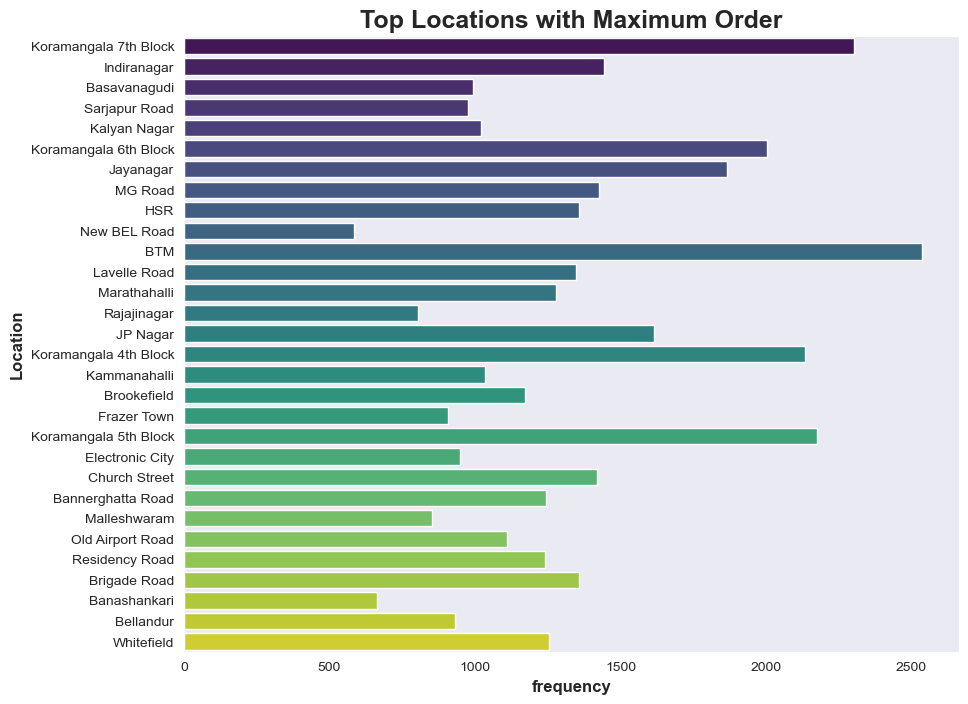

In [33]:
plt.figure(figsize=(10,8))
sns.set_style("dark")
sns.set_palette("Set2")
sns.countplot(df_copy['listed_in(city)'] ,palette="viridis")
plt.xlabel("frequency" , fontsize=12 , fontweight='bold')
plt.ylabel("Location" , fontsize=12 , fontweight='bold')
plt.title("Top Locations with Maximum Order" ,fontsize=18 , fontweight='bold')

In [34]:
df_copy.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost,listed_in(city)
0,New Friends,Yes,No,3.8,273,BTM,Casual Dining,"[Fritters, Lasagne, Biryani, Fish, Pasta, Drau...","North Indian, Continental, Chinese, Steak",900.0,Koramangala 7th Block
1,The Chennai Express,No,No,3.8,166,Indiranagar,Quick Bites,"[Idli, Filter Coffee, Vada Curry, Podi Dosa, S...","South Indian, Chinese",200.0,Indiranagar
2,The Blue Wagon - Kitchen,Yes,No,4.6,228,Jayanagar,Cafe,"[Pizza, Nachos, Garlic Maggi, Burgers, Cheese ...","Cafe, Beverages",400.0,Basavanagudi
3,Monsoon,No,No,2.8,12,Bellandur,Food Court,[Biryani],Continental,1000.0,Sarjapur Road
4,Ambur Biryani,No,No,3.7,0,Kammanahalli,Quick Bites,[Biryani],"Biryani, Kebab",250.0,Kalyan Nagar


# **Lets Observe top Restaurant type with Online Availability**

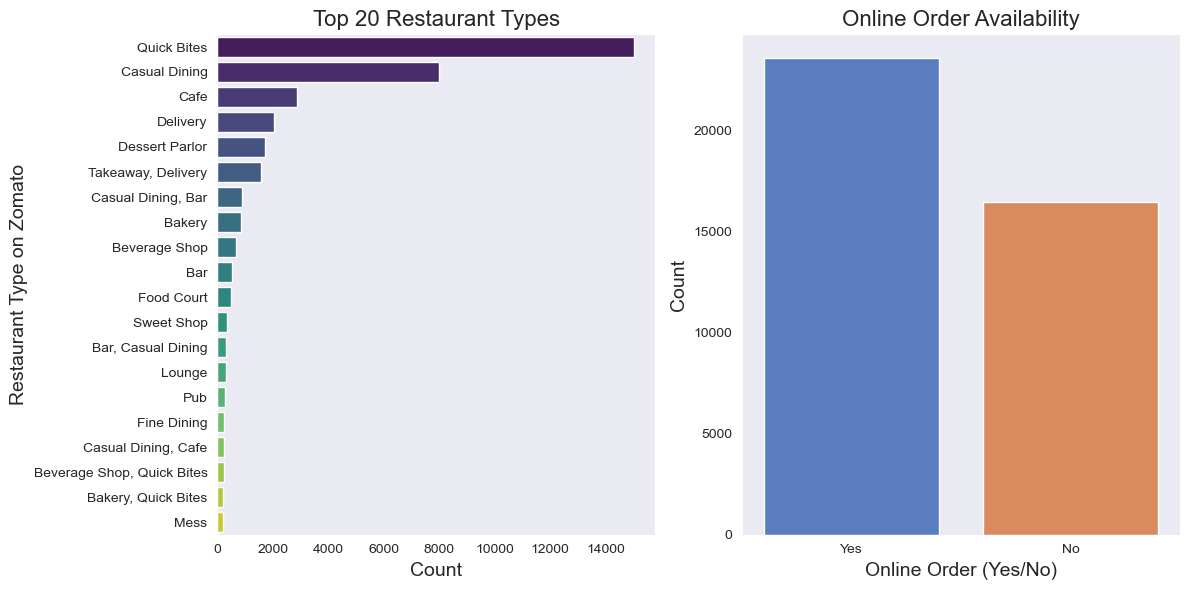

In [35]:
resrtaurant_type = df_copy["rest_type"].value_counts().sort_values(ascending=False).head(20)
online_order_available = df_copy["online_order"].value_counts()

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

# Barplot for restaurant types
sns.barplot(y=resrtaurant_type.index, x=resrtaurant_type.values, ax=ax1, palette="viridis")
ax1.set_title("Top 20 Restaurant Types", fontsize=16)
ax1.set_xlabel("Count", fontsize=14)
ax1.set_ylabel("Restaurant Type on Zomato", fontsize=14)

# Barplot for online order availability
sns.barplot(x=online_order_available.index, y=online_order_available.values, ax=ax2, palette="muted")
ax2.set_title("Online Order Availability", fontsize=16)
ax2.set_xlabel("Online Order (Yes/No)", fontsize=14)
ax2.set_ylabel("Count", fontsize=14)

# Display plots
plt.tight_layout()
plt.show()

# **Lets see Top Restaurants with highest no. orders**

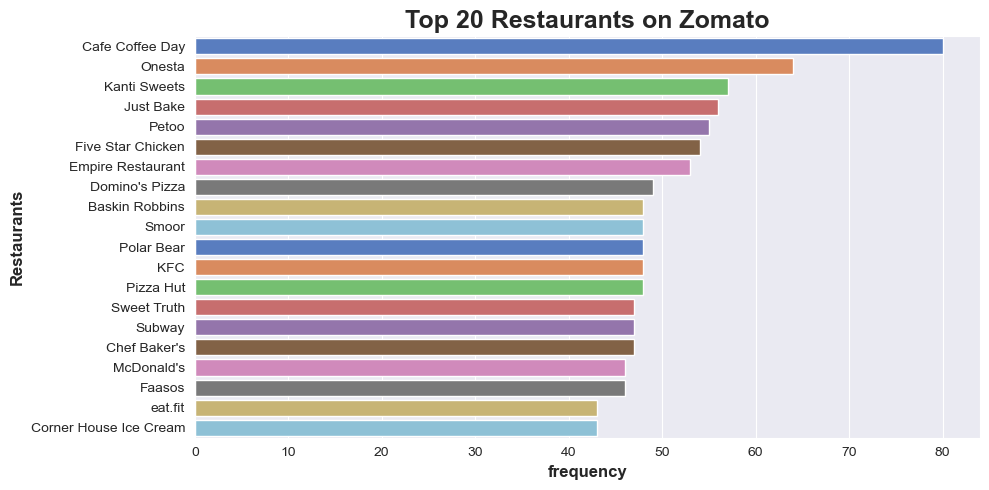

In [36]:
top_restaurants= df_copy["name"].value_counts().sort_values(ascending=False).head(20)
plt.figure(figsize=(10,5))
sns.set_style("darkgrid")
sns.set_palette("Set2")
sns.barplot(x=top_restaurants.values , y=top_restaurants.index ,palette="muted")
plt.xlabel("frequency" , fontsize=12 , fontweight='bold')
plt.ylabel("Restaurants" , fontsize=12 , fontweight='bold')
plt.title("Top 20 Restaurants on Zomato" ,fontsize=18 , fontweight='bold')
plt.tight_layout()
plt.show()


In [37]:
df_copy.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost',
       'listed_in(city)'],
      dtype='object')

# **Let's Check the Restaurants with the Most Online Orders on Zomato**

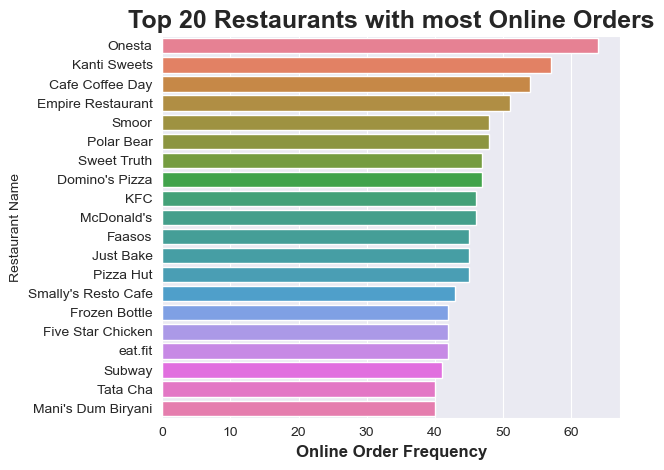

In [38]:
online_restro=df_copy[df_copy['online_order']=="Yes"]
online_order_by_restaurant=online_restro.groupby("name")['online_order'].count().sort_values(ascending=False).reset_index().head(20)
online_order_by_restaurant.columns = ["Restaurant Name", "Online Orders"]
sns.barplot(x=online_order_by_restaurant["Online Orders"] , y=online_order_by_restaurant["Restaurant Name"] , palette="husl")
plt.xlabel("Restaurants" , fontsize=12 , fontweight='bold')
plt.xlabel("Online Order Frequency" , fontsize=12 , fontweight='bold')
plt.title("Top 20 Restaurants with most Online Orders" ,fontsize=18 , fontweight='bold')
plt.tight_layout()
plt.show()

# **Lets see  Common/Average rating**

In [39]:
df["rate"].unique()

array([3.8, 4.6, 2.8, 3.7, 4. , 3.6, 4.1, 3.2, 3.3, 3.9, 4.4, 3.4, 2.9,
       3.1, 3.5, 2.6, 4.2, 2.7, 3. , 4.3, 2.3, 4.9, 4.5, 2.5, 2.4, 4.7,
       4.8, 2. , 2.2, 2.1, 1.8])

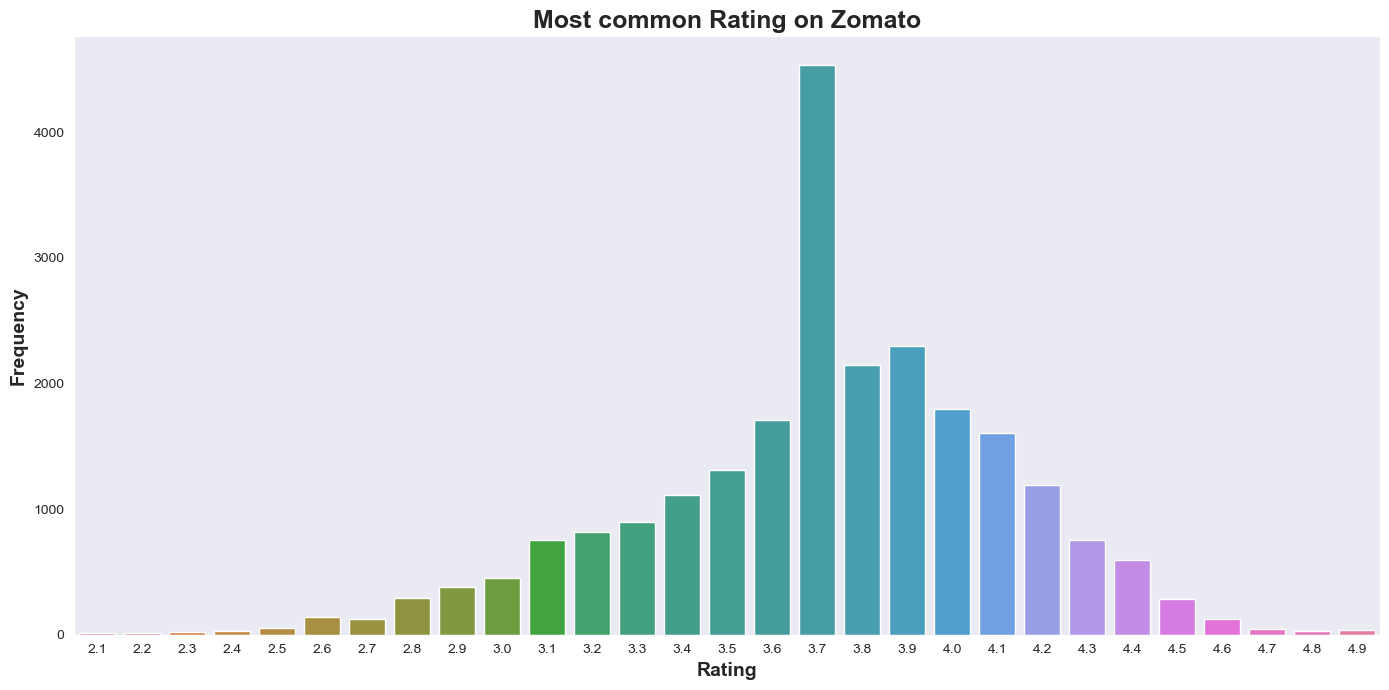

In [40]:
online_restro=df_copy[df_copy['online_order']=="Yes"]
common_rating=online_restro["rate"].value_counts().reset_index()
plt.figure(figsize=(14,7))
sns.set_style("dark")
sns.barplot(data=common_rating , x='rate' , y="count" , palette="husl")
plt.xlabel("Rating" , fontsize=14, fontweight="bold")
plt.ylabel("Frequency" ,fontsize=14 , fontweight="bold")
plt.title("Most common Rating on Zomato" , fontsize=18 , fontweight="bold")
plt.tight_layout()
plt.show()


# **Let's Observe Restaurants Offering Online Orders with Respect to Their Ratings**

In [41]:
restro_average_rating=online_restro.groupby("name")["rate"].mean().reset_index()
restro_average_rating

,name,rate
0,#L-81 Cafe,3.900000
1,#refuel,3.700000
2,'Brahmins' Thatte Idli,3.700000
3,1000 B.C,3.200000
4,11 to 11 Express Biriyanis,3.500000
...,...,...
4273,Zyara,3.875000
4274,eat.fit,4.354762
4275,iCloud Irany Cafe,3.700000
4276,iSpice Resto Cafe,3.700000


# **Lets check Restaurants more than average rating**

In [42]:
best_rating_restro=restro_average_rating[restro_average_rating["rate"]>3.7]
best_rating_restro



,name,rate
0,#L-81 Cafe,3.900000
1,#refuel,3.700000
5,1441 Pizzeria,4.033333
6,1522 - The Pub,4.200000
7,154 Breakfast Club,4.000000
...,...,...
4269,Zodiac - Fortune Select JP Cosmos Hotel,3.800000
4271,Zoey's,4.300000
4273,Zyara,3.875000
4274,eat.fit,4.354762


# **lets check Top Restro on Zomato with most rating**

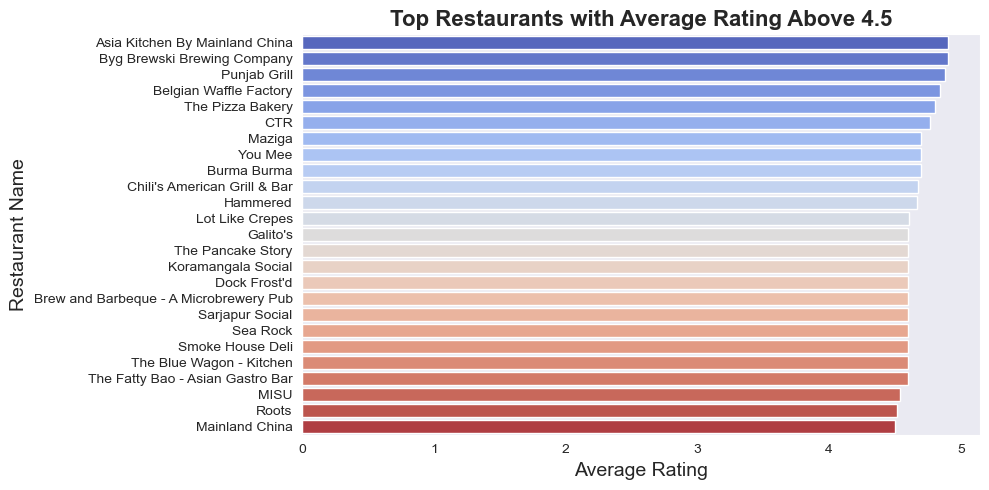

In [43]:
top_rated_restro= best_rating_restro[best_rating_restro["rate"]>4.5].sort_values(by="rate" ,ascending=False).reset_index().drop("index" , axis=1)

# Plotting top-rated restaurants
plt.figure(figsize=(10, 5))
sns.barplot(
    y="name", x="rate", data=top_rated_restro, palette="coolwarm"
)

# Adding titles and labels
plt.title("Top Restaurants with Average Rating Above 4.5", fontsize=16, fontweight='bold')
plt.xlabel("Average Rating", fontsize=14)
plt.ylabel("Restaurant Name", fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()

# **Lets Observe Pre-Booking Facilty on Zomato**

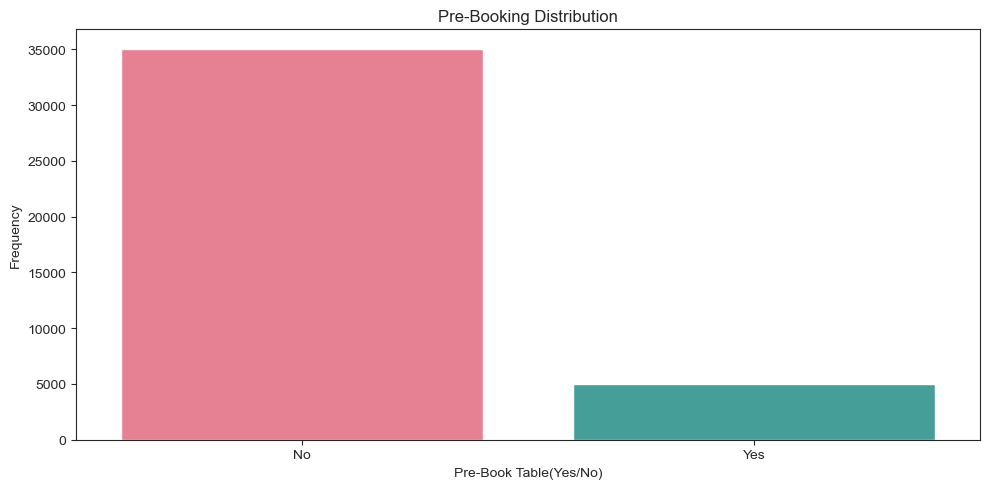

In [44]:
plt.figure(figsize=(10,5))
sns.set_style("ticks")
sns.countplot(x=df_copy["book_table"] , palette="husl")
plt.xlabel("Pre-Book Table(Yes/No)")
plt.ylabel("Frequency")
plt.title("Pre-Booking Distribution")
plt.tight_layout()
plt.show()

# **Lets check Top Restaurants with Pre-book Facility Available or not**

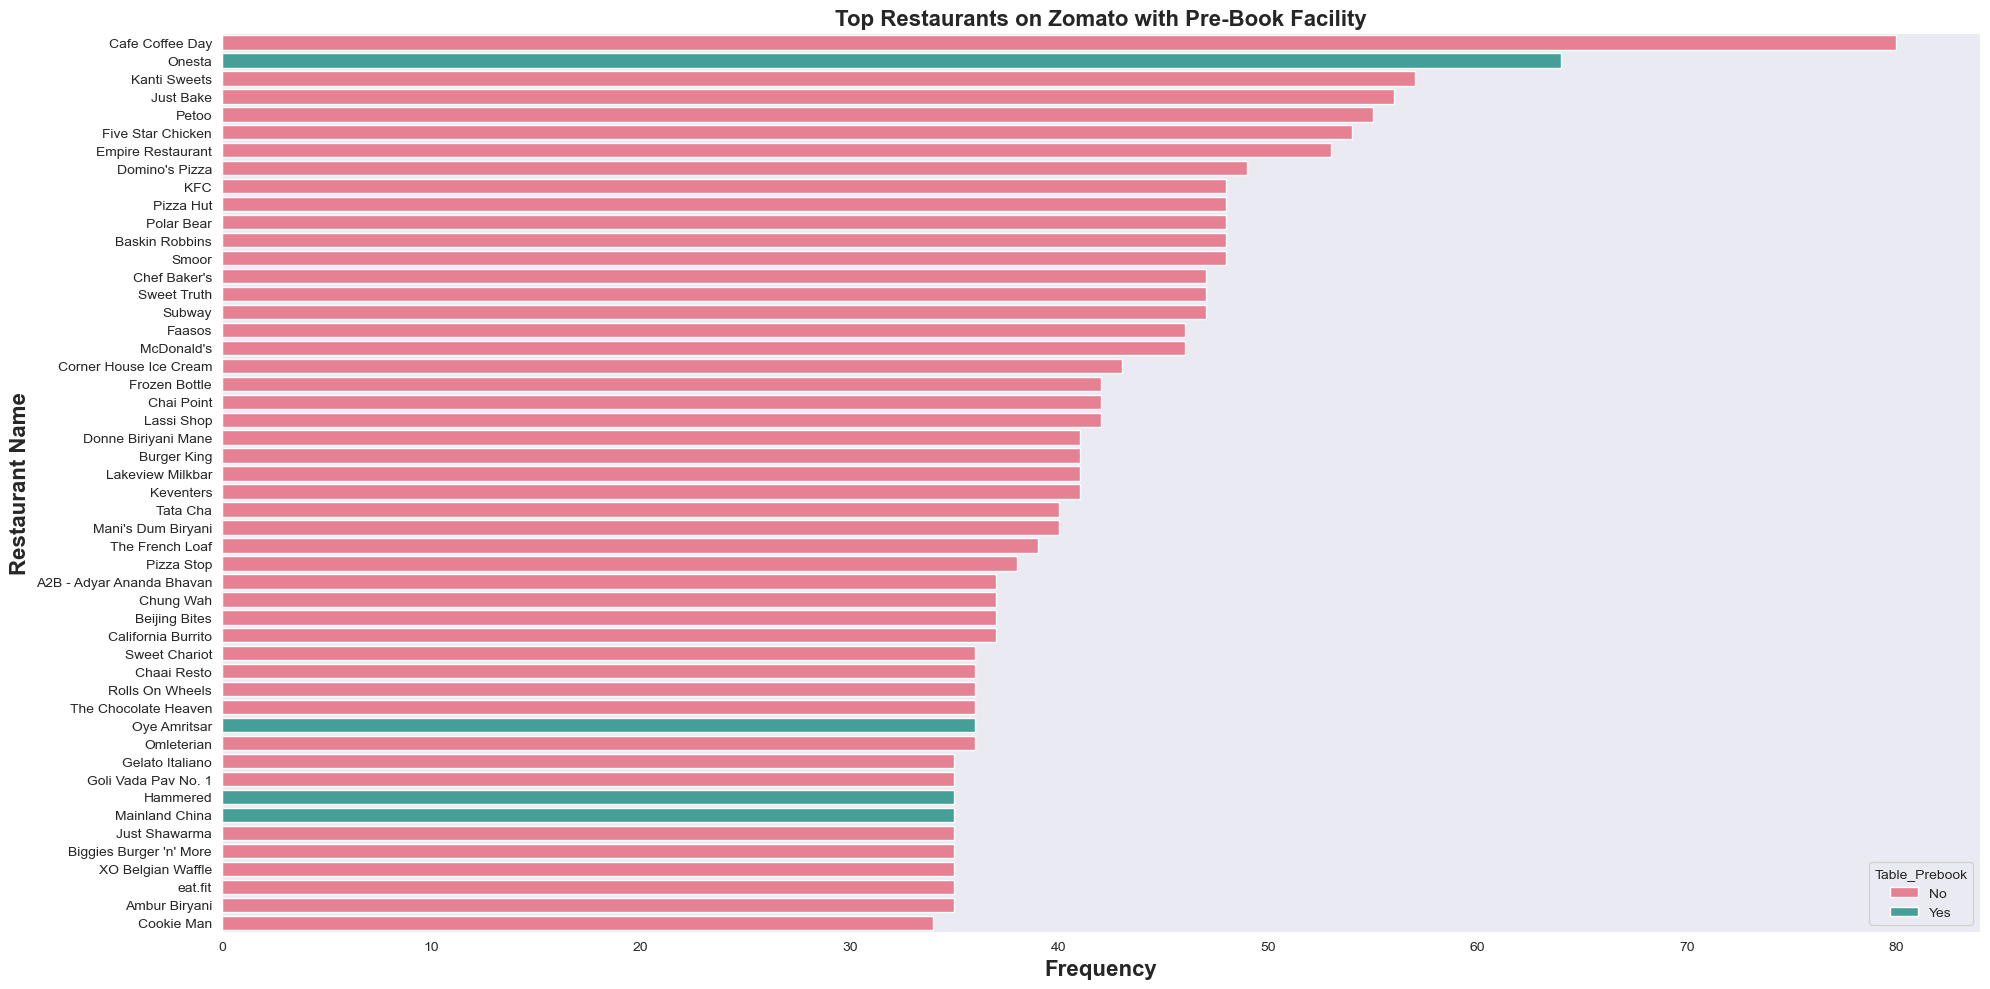

In [45]:
top_pre_book_restro_= df_copy[["name" ,"book_table"]].value_counts().sort_values(ascending=False).reset_index().head(50)
top_pre_book_restro_.columns=["Restaurant Name" , "Table_Prebook" , "Frequency"]
top_pre_book_restro_
plt.figure(figsize=(20,10))
sns.set_style("dark")
sns.barplot(data=top_pre_book_restro_ , x="Frequency" , y="Restaurant Name" , hue='Table_Prebook' , palette="husl")
plt.xlabel("Frequency" , fontsize=16 , fontweight="bold")
plt.ylabel("Restaurant Name" , fontsize=16 , fontweight="bold")
plt.title("Top Restaurants on Zomato with Pre-Book Facility" , fontsize=16 , fontweight="bold")
plt.tight_layout()
plt.show()

# **Lets observe cuisines with positive ratings and their respective percentage scores**

In [46]:
cuisines_rating= df_copy.groupby("cuisines")["rate"].mean().sort_values(ascending=False).reset_index()
cuisines_rating["Positive Rating"]= cuisines_rating["rate"] /5 *100
cuisines_rating.columns=["Restaurant name" , "Rating" , "Positive Rating Percentage"]
cuisines_rating

,Restaurant name,Rating,Positive Rating Percentage
0,"Asian, Chinese, Thai, Momos",4.900000,98.000000
1,"Continental, North Indian, Italian, South Indi...",4.900000,98.000000
2,"Healthy Food, Salad, Mediterranean",4.900000,98.000000
3,"Asian, Mediterranean, North Indian, BBQ",4.820000,96.400000
4,"North Indian, European, Mediterranean, BBQ",4.800000,96.000000
...,...,...,...
2634,"Andhra, North Indian, Chinese, Mangalorean",2.500000,50.000000
2635,"North Indian, Chinese, Arabian, Biryani, Fast ...",2.466667,49.333333
2636,"Chinese, European",2.400000,48.000000
2637,"Healthy Food, Salad, Fast Food",2.400000,48.000000


# **Lets Identify Outtliers from Our Target feature rate and also num feature such as approx_cost**

In [47]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost,listed_in(city)
0,New Friends,Yes,No,3.8,273,BTM,Casual Dining,"[Fritters, Lasagne, Biryani, Fish, Pasta, Drau...","North Indian, Continental, Chinese, Steak",900.0,Koramangala 7th Block
1,The Chennai Express,No,No,3.8,166,Indiranagar,Quick Bites,"[Idli, Filter Coffee, Vada Curry, Podi Dosa, S...","South Indian, Chinese",200.0,Indiranagar
2,The Blue Wagon - Kitchen,Yes,No,4.6,228,Jayanagar,Cafe,"[Pizza, Nachos, Garlic Maggi, Burgers, Cheese ...","Cafe, Beverages",400.0,Basavanagudi
3,Monsoon,No,No,2.8,12,Bellandur,Food Court,[Biryani],Continental,1000.0,Sarjapur Road
4,Ambur Biryani,No,No,3.7,0,Kammanahalli,Quick Bites,[Biryani],"Biryani, Kebab",250.0,Kalyan Nagar


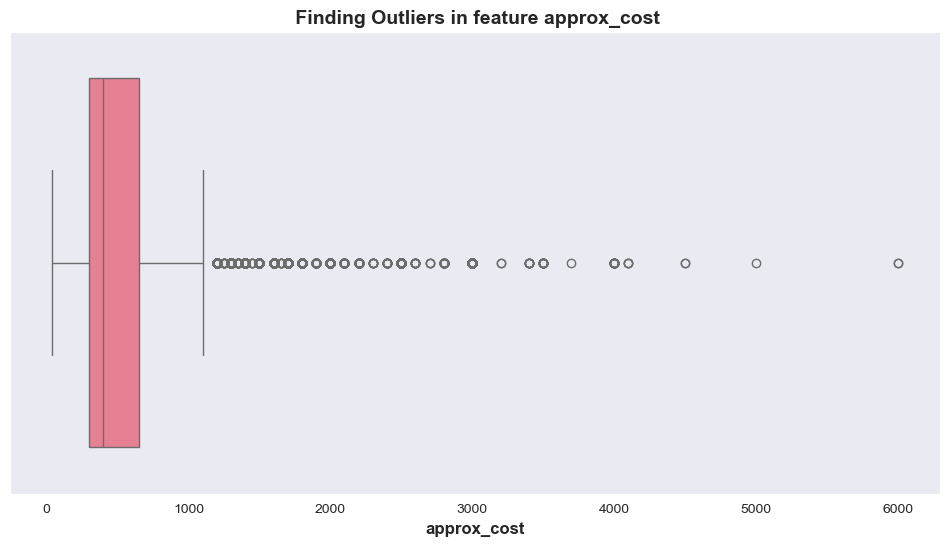

In [48]:
columns = ["approx_cost"]
for column in columns:
     plt.figure(figsize=(12,6))
     sns.set_style("dark")
     sns.boxplot(x=df_copy[column] , palette="husl" , flierprops=dict(marker='o', color='red', markersize=6))
     plt.xlabel(column , fontsize=12 , fontweight="bold")
     plt.title(f' Finding Outliers in feature {column}' , fontsize=14, fontweight="bold")

# **Lets replace Outliers with lower and higher limit**



In [49]:

def outliers_threshold(data, columns):
    """ 
    =========================================================================================
    This function replaces outliers with lower and higher bounds for provided features/columns.
    
    data: pd.DataFrame
        The dataframe containing the features/columns.
    
    columns: list of str
        List of column names (features) in which outliers need to be handled.
    
    Returns:
    --------
    lower_limits: dict
        Dictionary containing the lower limit for each column.
    
    higher_limits: dict
        Dictionary containing the higher limit for each column.
    ===========================================================================================
    """
    
    # Initialize dictionaries to store the limits for each column
    lower_limits = {}
    higher_limits = {}
    
    # Ensure the provided columns exist in the dataframe
    missing_columns = [col for col in columns if col not in data.columns]
    if missing_columns:
        raise ValueError(f"Columns not found in the dataframe: {', '.join(missing_columns)}")
    
    # Ensure all columns contain numeric data
    for column in columns:
        if not pd.api.types.is_numeric_dtype(data[column]):
            raise ValueError(f"Column '{column}' is not numeric. Please provide numeric columns.")
    
    # Loop through the columns to calculate IQR and handle outliers
    for column in columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        
        # Calculate lower and higher bounds
        lower_limit = Q1 - 1.5 * IQR
        higher_limit = Q3 + 1.5 * IQR
        
        # Store the limits for later use
        lower_limits[column] = lower_limit
        higher_limits[column] = higher_limit
        
        # Handle outliers by replacing them with the respective limits
        data[column] = np.where(data[column] < lower_limit, lower_limit, data[column])
        data[column] = np.where(data[column] > higher_limit, higher_limit, data[column])
    
    # Return the lower and higher bounds for each column
    return lower_limits, higher_limits


In [50]:
columns = ["approx_cost"]
lower_limit , higher_limit = outliers_threshold(df_copy , columns)

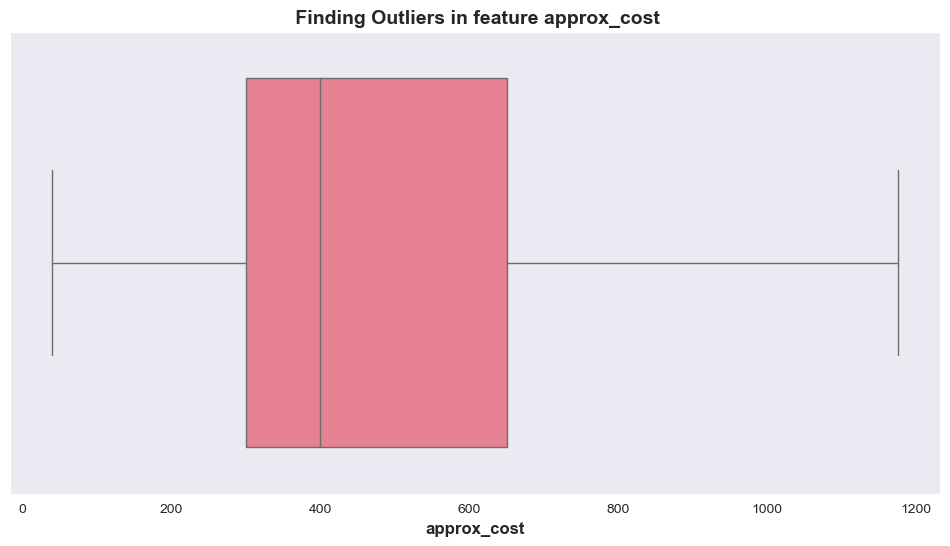

In [52]:
columns = ["approx_cost"]
for column in columns:
     plt.figure(figsize=(12,6))
     sns.set_style("dark")
     sns.boxplot(x=df_copy[column] , palette="husl" , flierprops=dict(marker='o', color='red', markersize=6))
     plt.xlabel(column , fontsize=12 , fontweight="bold")
     plt.title(f' Finding Outliers in feature {column}' , fontsize=14, fontweight="bold")

# **Outliers are cleaned**